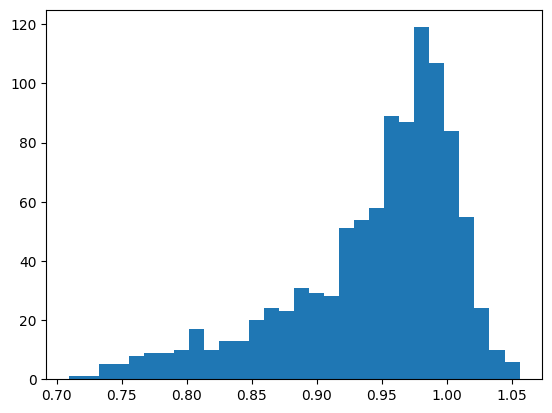

In [67]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
import sklearn 
from random import sample
from sklearn.neighbors import KernelDensity
import scipy

sigma=0.02
mu=1

chi=np.random.uniform(0,1,1000)
M=np.random.normal(mu,sigma,1000)

def f(X): 
    return np.sqrt((1+np.sqrt(1-X**2))/2)

M_irr=M*f(chi)
plt.hist(M_irr,30)
plt.show()
  

Using KDE

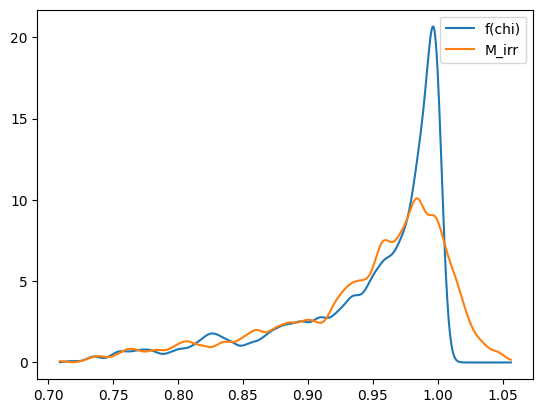

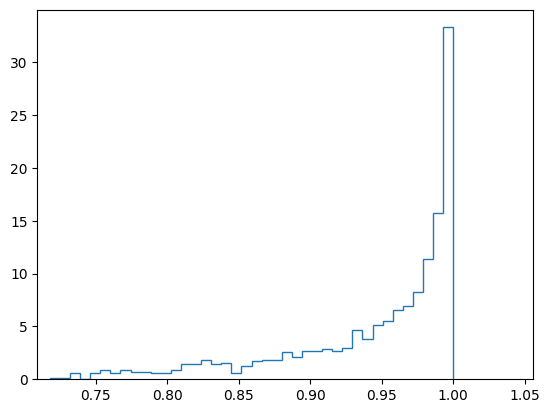

In [ ]:
xgrid = np.linspace(M_irr.min(),M_irr.max(),1000) #x of KDE 

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):

    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

PDFGaussian = kde_sklearn(M_irr,bandwidth=0.005,kernel="gaussian") 
PDFfchi = kde_sklearn(f(chi),bandwidth=0.005,kernel="gaussian")  
plt.plot(xgrid,PDFfchi, label='f(chi)') 
plt.plot(xgrid,PDFGaussian, label='M_irr')
plt.legend()
plt.show()

#Plotting the PDF of M_irr and f(chi)

def f_pdf(f):                               #pdf of chi 
    return 2*(2*f**2-1)/np.sqrt(1-f**2)

def to_int(f,Mirr,sigma,mu):          
    return np.exp((-Mirr/f-mu)**2/(2*sigma**2))*f_pdf(f)

import scipy.integrate as integrate
def Mirr_pdf(Mirr,f,mu,sigma):                     #pdf of M_irr
    integral=integrate.quad(to_int(f,Mirr,sigma,mu),1/np.sqrt(2),1)
    return np.sqrt(2/np.pi)/sigma*integral(Mirr)

minf=np.min(f(chi))
maxf=np.max(f(chi))

xgrid2 = np.linspace(minf,maxf,1000) 
# plt.hist(f(chi),bins=40, histtype='step', density=True, label='f(chi)') 
# plt.xlim(np.min(xgrid), np.max(xgrid))



nor=integrate.quad(f_pdf,minf,maxf) #nel codominio di f f_pdf è normalizzata



### Ks Comparison ###

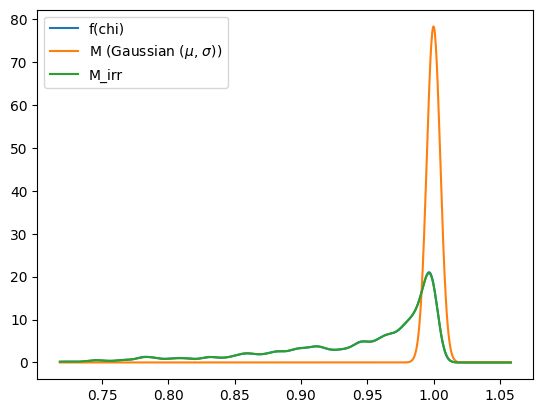

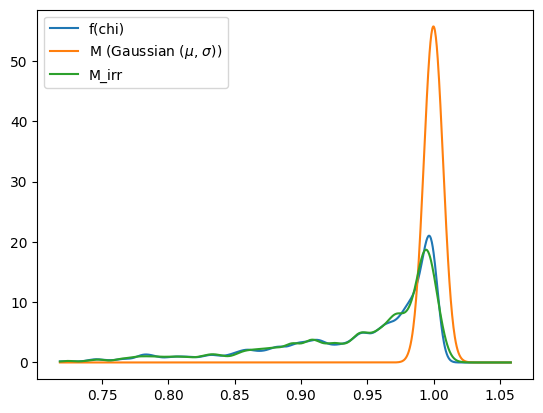

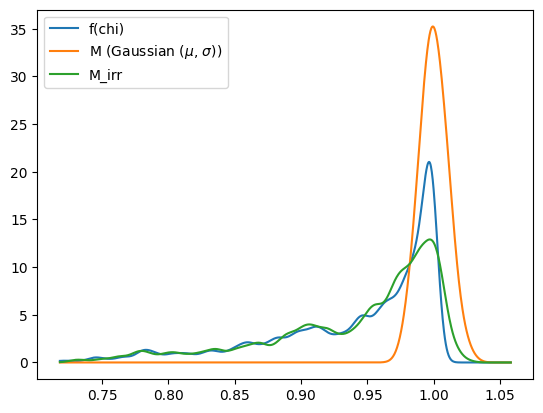

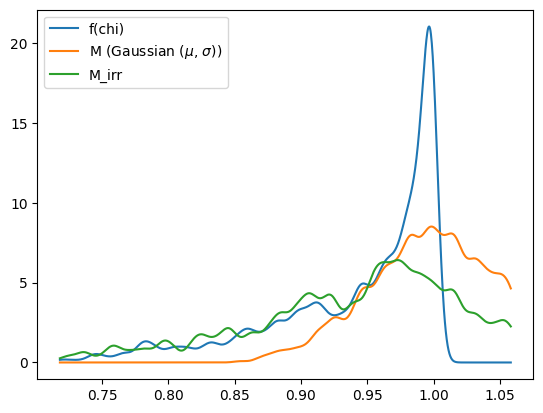

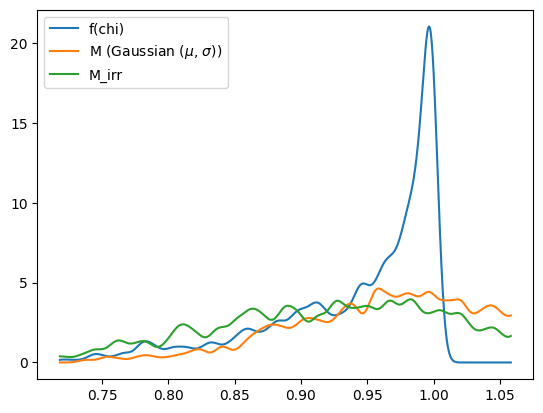

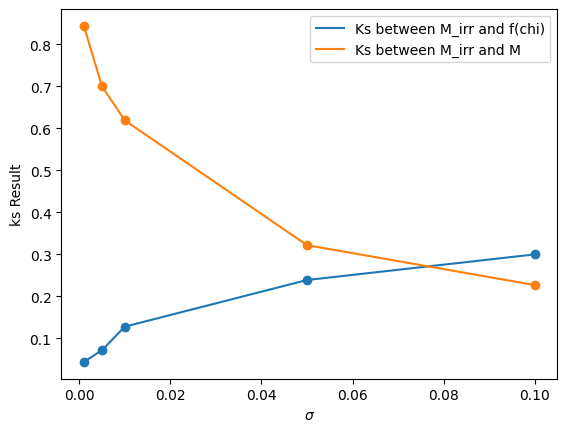

In [56]:
ks1=[]
ks2=[]

sigmas=[0.001,0.005,0.01,0.05,0.1]
for i in sigmas:
    Mk=np.random.normal(mu,i,1000)
    Mk_irr=Mk*f(chi)

    PDFChi = kde_sklearn(f(chi),bandwidth=0.005,kernel="gaussian") #plot always same f(chi)
    PDFMass = kde_sklearn(Mk,bandwidth=0.005,kernel="gaussian")  
    PDFMirr = kde_sklearn(Mk_irr,bandwidth=0.005,kernel="gaussian")  

    plt.plot(xgrid,PDFChi, label="f(chi)")
    plt.plot(xgrid,PDFMass, label=r"M (Gaussian ($\mu$, $\sigma$))")
    plt.plot(xgrid,PDFMirr, label="M_irr")
    
    plt.legend()
    plt.show()

    ks1.append(scipy.stats.ks_2samp(Mk_irr,f(chi)).statistic)
    ks2.append(scipy.stats.ks_2samp(Mk_irr,Mk).statistic)

plt.scatter(sigmas,ks1)
plt.plot(sigmas,ks1, label="Ks between M_irr and f(chi)")
plt.scatter(sigmas,ks2)
plt.plot(sigmas,ks2, label="Ks between M_irr and M")
plt.legend()
plt.xlabel(r"$\sigma$")
plt.ylabel("ks Result")
plt.show()
